# End-to-End Machine Learning Project

When training machine learning algorithms, it is important that we do not forget about the goal of the project and how will the algorithm be used in practice. The application will almost always drive the algorithm design and choices made during all steps in a machine learning systems. These include: data collection, model design, performance metrics, hyperparameter tuning, deployment and maintenance.

The main steps you will go through in this course and your projects are: 

1. Look at the big picture. 
2. Get the data. 
3. Discover and visualize the data to gain insights. 
4. Prepare the data for Machine Learning algorithms. 
5. Select a model and train it. 
6. Fine-tune your model. 
7. Present your solution. 
8. Launch, monitor, and maintain your system.

# California District's Median Housing Price

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
import pandas as pd

housing = pd.read_csv('datasets\\housing.csv')
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Step 4: Prepare the Data for Machine Learning Algorithms

## Test Set

Before carrying *experimental design* choices such as model selection and fine-tuning the model, it is important that we create a dataset where we can test the model's **generalization** ability. This is often done by allocating a subset of the samples as a **test set**.

The role of the test set is to evaluate the model's performance and generalization. It should not be used *at all* during the training phase in order to avoid the *data snooping bias* that often happens.

We typically partition the data *at random* into **train set** and **test set**. Typically splits are 80/20%.

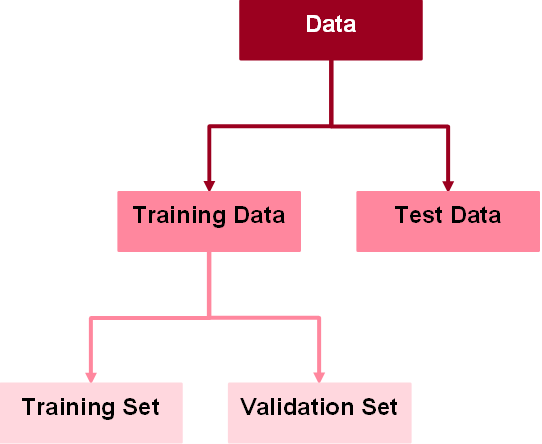

In [2]:
from IPython.display import Image
Image('figures\\train_test_partition.png', width=300)

```Scikit-Learn``` provides a few functions to split datasets into multiple subsets in various ways. The simplest function is ```train_test_split()```

* It includes a ```random_state``` parameter that allows you to set the random generator seed. If you run the program again and don't fix the random state, it will generate a different test set! Over time, you (or your Machine Learning algorithms) will get to see the whole dataset, which is what you want to avoid.
    * But if your dataset is being periodically updated, the solution above will not work.

    * Better solution is to use a **sample identifier** and for each new sample determine whether it should go to the train set or test set.
    
    * When using ```pandas``` dataframes, we can use the dataframe index as the sample identifier.

* You can pass it multiple datasets with an identical number of rows, and it will split them on the same indices (this is very useful, for example, if you have a separate ```DataFrame``` for labels).

In [3]:
from sklearn.model_selection import train_test_split  # Importing the train_test_split function from scikit-learn

# The train_test_split function is used to split a dataset into training and testing subsets.
# It helps in evaluating the performance of machine learning models by providing separate 
# datasets for training the model and testing it.

# This next line, when run in a Jupyter Notebook or IPython, displays documentation for the function.

train_test_split?

In [4]:
# Splitting the 'housing' dataset into training and testing sets using train_test_split

train_set, test_set = train_test_split(
    housing,         # The dataset to be split (assumed to be a DataFrame or array-like structure)
    test_size=0.2,   # Specifies that 20% of the data will be allocated to the test set, and 80% to the train set
    random_state=42, # Ensures reproducibility by setting a seed for the random number generator
    shuffle=True     # Shuffles the data before splitting to ensure randomness in the division
)

# After execution, 'train_set' will contain 80% of the original data, and 'test_set' will contain 20%.
# This split helps in training the model on one portion of the data and evaluating it on unseen data.


In [5]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,<1H OCEAN
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,INLAND
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,<1H OCEAN
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,<1H OCEAN


In [6]:
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,263300.0,<1H OCEAN
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,266800.0,NEAR OCEAN
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,500001.0,<1H OCEAN
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,72300.0,INLAND


From the previous correlation results, we saw that median income has a moderate predictive value to predict the median house price:

In [7]:
corr_matrix = housing.corr(method='pearson', numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

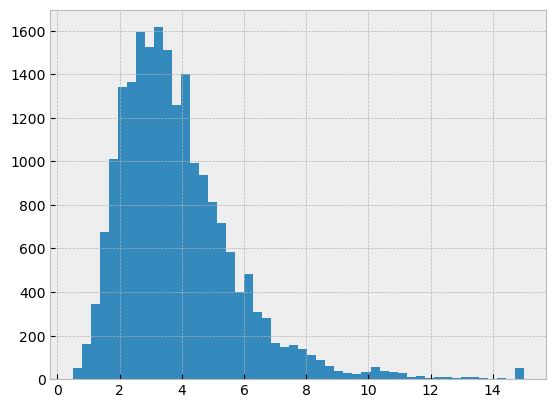

In [8]:
housing['median_income'].hist(bins=50);

Since this **feature** (or **attribute**) is so valuable, we may want to maintain the prior probabilities of each "category" of median income in the train and test sets.

<div class="alert alert-info" role="alert">
    <b>Stratification</b>
    
Process of partitioning the dataset into subsets while preserving the (categorical) classes prior probabilities the same as in the original dataset. 
    
For example, if a class has 20 percent examples in the whole dataset, in all samples drawn from the dataset, it should also have approximately 20 percent examples in each subset.
</div>

Let's visualize the feature ```median_income``` to gain more insights:

In [9]:
# About 95% of the samples lie in the interval [a, b]

# Calculate the lower bound 'a' of the 95% confidence interval for 'median_income'
a = housing['median_income'].mean() - 1.96 * housing['median_income'].std(ddof=1)

# Calculate the upper bound 'b' of the 95% confidence interval for 'median_income'
b = housing['median_income'].mean() + 1.96 * housing['median_income'].std(ddof=1)

# Display the calculated confidence interval bounds
a, b


(np.float64(0.14702043573424994), np.float64(7.594321570079703))

In [10]:
# Calculate the proportion of 'median_income' values that lie within the computed confidence interval [a, b]

len(
    np.where((housing['median_income'] >= a) & (housing['median_income'] <= b))[0]
) / len(housing['median_income'])


0.9570736434108527

In [11]:
# Generate summary statistics for the 'median_income' column in the 'housing' dataset
housing['median_income'].describe()


count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

In [12]:
# Categorize 'median_income' column to perform stratified splitting

income_cat = pd.cut(
    housing['median_income'],  # The 'median_income' column to be categorized
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],  # Define income range bins
    labels=[1, 2, 3, 4, 5]  # Assign category labels corresponding to the bins
)

# Display the categorized income values
income_cat


0        5
1        5
2        5
3        4
4        3
        ..
20635    2
20636    2
20637    2
20638    2
20639    2
Name: median_income, Length: 20640, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [13]:
housing['median_income']

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: median_income, Length: 20640, dtype: float64

In [14]:
# Perform stratified splitting of the 'housing' dataset based on the 'income_cat' categories

train_set, test_set, income_cat_train, income_cat_test = train_test_split(
    housing,         # The original dataset to be split
    income_cat,      # The stratification criterion (categorical income categories)
    test_size=0.2,   # Specifies that 20% of the data will be allocated to the test set
    shuffle=True,    # Randomly shuffle the data before splitting to ensure randomness
    random_state=42, # Ensures reproducibility of the split by fixing the random seed
    stratify=income_cat  # Ensures the stratified split by preserving the income category distribution
)


In [15]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN


In [16]:
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN


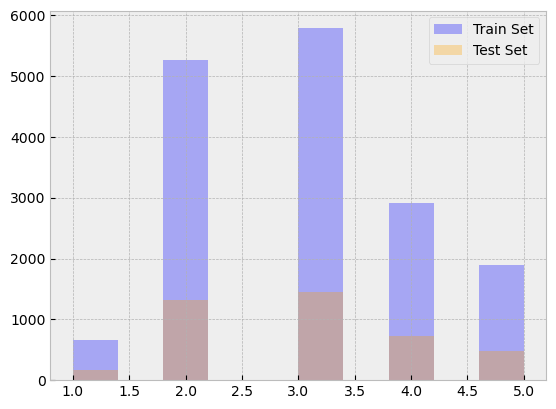

In [17]:
plt.hist(income_cat_train, color='blue', label='Train Set', alpha=0.3)
plt.hist(income_cat_test, color='orange', label='Test Set', alpha=0.3)
plt.legend();

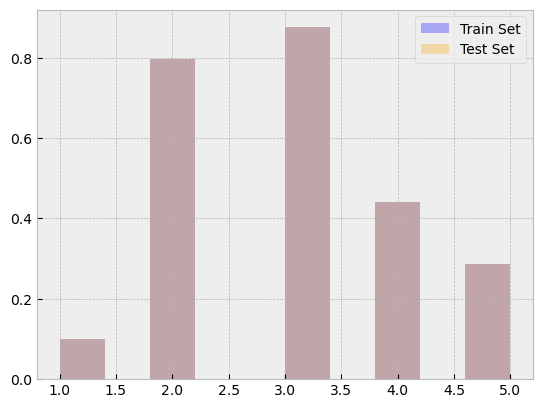

In [18]:
plt.hist(income_cat_train, density=True, color='blue', label='Train Set', alpha=0.3)
plt.hist(income_cat_test, density=True, color='orange', label='Test Set', alpha=0.3)
plt.legend();

## Training Set

In preparing your data for ML algorithms it is often convenient and efficient to build functions to automate feature extraction and data cleaning. This provides with:

1. reproducibility on any dataset,
2. reusability, 
3. apply the same transformations to the test set,
4. ability to incorporate it with your live system, and 
5. carry experiments for design choices.

These transformations can be applied to the features only, the target values only or both. For convenience, let's separate them into two variables:

---

In [19]:
# TRAINING: Target Vector and Feature/Input Matrix

# Extract the target variable (dependent variable) from the training set
t_train = train_set['median_house_value'].copy()

# Create the feature matrix by dropping the target variable from the training set
X_train = train_set.drop(labels='median_house_value', axis=1)  # axis=1 specifies column-wise operation

# Display the shapes of the target vector and feature matrix
t_train.shape, X_train.shape


((16512,), (16512, 9))

In [20]:
# TEST: Target Vector and Feature/Input Matrix

t_test = test_set['median_house_value'].copy()
X_test = test_set.drop(labels='median_house_value', axis=1)

t_test.shape, X_test.shape

((4128,), (4128, 9))

## Data Cleaning

In case features have some missing values, you have three options to proceed: 

1. Get rid of the corresponding sample. 

2. Get rid of the whole feature. 

3. Set the values to some value (zero, the mean, the median, etc.). 

```pandas``` dataframes have readily available methods to accomplish this: ```dropna()```, ```drop()```, and ```fillna()```.

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


In [22]:
# option 1: drop the rows that are empty
# X_train.dropna(subset=['total_bedrooms'])

# option 2: drop the entire column
# X_train.drop('total_bedrooms', axis=1)

# option 3: fill in missing entries with the statistic median
# median = X_train['total_bedrooms'].median()
# X_train['total_bedrooms'].fillna(median, inplace=True)

```scikit-learn``` provides a class to handle missing data: ```SimpleImputer```.

In [23]:
from sklearn.impute import SimpleImputer

SimpleImputer?

In [24]:
#sklearn object
imputer = SimpleImputer(strategy='median')
imputer

SimpleImputer(strategy='median')

Since the median can only be computed on numerical attributes, you need to create a copy of the data without the text feature ```ocean_proximity```:

In [25]:
# Extract numerical features/attributes 

X_train_num = X_train.drop('ocean_proximity', axis=1)

In [26]:
# Train or computing the median for each attribute/feature
imputer.fit(X_train_num)

imputer

SimpleImputer(strategy='median')

In ```scikit-learn```, all the estimator's hyperparameters are accessible directly via public instance variables (e.g., ```imputer.strategy```), and all the estimator's learned parameters are accessible via public instance variables with an underscore suffix (e.g., ```imputer.statistics_```).

In [27]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [28]:
X_train_num.median()

longitude             -118.51000
latitude                34.26000
housing_median_age      29.00000
total_rooms           2119.00000
total_bedrooms         433.00000
population            1164.00000
households             408.00000
median_income            3.54155
dtype: float64

In [29]:
# imputing missign values

X = imputer.transform(X_train_num)
X.shape

(16512, 8)

In [30]:
## This step is not required - I'm using this for better visualization of the data

housing_tr = pd.DataFrame(X, 
                          columns=X_train_num.columns, 
                          index=X_train_num.index)

housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964
...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964


In [31]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


## Handling Text and Categorical Inputs

In [32]:
# Extract the categorical feature 'ocean_proximity' from the housing dataset

X_train_cat = housing[['ocean_proximity']]  # Selecting the 'ocean_proximity' column as a DataFrame

# Display the extracted categorical feature
X_train_cat


,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


Let's convert the categories to numerical representations. There are 2 options:

1. **Integer encoding**. Each category is encoded to a discrete number (1, 2, 3, etc.). The issue with integer encoding is the fact that we will inject an implicit order in the categories (1 < 2, 1 < 3, etc.) that may not reflect the (physical) properties that feature is describing.

2. **One-Hot Encoding**. Each category is encoded as a sparse vector. That vector will have as many entries as there are categories. They will all be zero except at the integer location that category belongs, in which it will have an entry equal to 1. The challenge with one-hot encoding is that these representations can be very sparse and pose challenges later on in the algorithm design and training.

    * **Binary Encoding**. Choose a binary (or other base) encoding to reduce sparsity while not imposing implicit ordering.
    
3. **Representation Learning**. Alternatively, you could replace each category with a learnable, low-dimensional vector called an *embedding*. Each category's representation would be learned during training. We will see this later in the course.

In [33]:
# Option 1

from sklearn.preprocessing import OrdinalEncoder 

OrdinalEncoder?

In [34]:
ordinal_encoder = OrdinalEncoder()
ordinal_encoder

OrdinalEncoder()

In [35]:
# Encode the categorical feature 'ocean_proximity' using ordinal encoding

X_train_cat_encoded = ordinal_encoder.fit_transform(X_train_cat)

# Note: fit_transform should ONLY be used with the TRAINING dataset
# For the TEST set, we use the TRANSFORM method to prevent data leakage.

ordinal_encoder  # Display the trained ordinal encoder object


OrdinalEncoder()

In [36]:
X_train_cat_encoded

array([[3.],
       [3.],
       [3.],
       ...,
       [1.],
       [1.],
       [1.]])

In [37]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [38]:
# Option 2

from sklearn.preprocessing import OneHotEncoder

OneHotEncoder?

In [39]:
cat_encoder = OneHotEncoder()

cat_encoder

OneHotEncoder()

In [40]:
X_train_cat_1hot = cat_encoder.fit_transform(X_train_cat)

X_train_cat_1hot

<20640x5 sparse matrix of type '<class 'numpy.float64'>'
	with 20640 stored elements in Compressed Sparse Row format>

In [41]:
X_train_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

## Feature Scaling

One of the most important transformations you need to apply to your data is feature scaling. With few exceptions, Machine Learning algorithms don't perform well when the input numerical attributes have very different scales. 

* Note that scaling the target values is generally **not** required. 

There are two common ways to get all attributes to have the same scale: 

1. **Min-Max Scaling**. Values are shifted and rescaled so that they end up ranging from 0 to 1.
    * Highly affected by outliers.
    

2. **Standardization**. First it subtracts the mean value (so standardized values always have a zero mean), and then it divides by the standard deviation so that the resulting distribution has unit variance.
    * Less affected by outliers
    * Gaussianity assumptions

<div class="alert alert-warning" role="alert">
    
As with all the transformations, it is important to fit the scalers to the training data only, not to the full dataset (including the test set). Only then can you use them to transform the training set and the test set (and new data).
</div>

---

---